# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [47]:
# Import the library
import cv2
from PIL import Image, ImageOps
from skimage import data
import numpy as np
from IPython.display import display

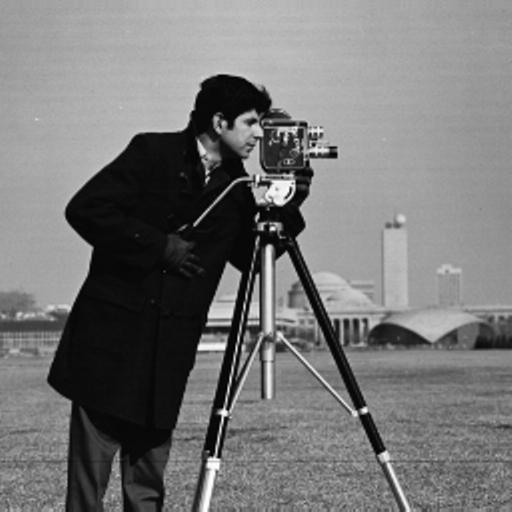

In [48]:
# ── Load image ────────────────────────────────────
original_image = Image.open("images/output.png")

display(original_image)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [49]:
# Get the size of the image
width, height = original_image.size

# scaling factors
cx = 2
cy = 2


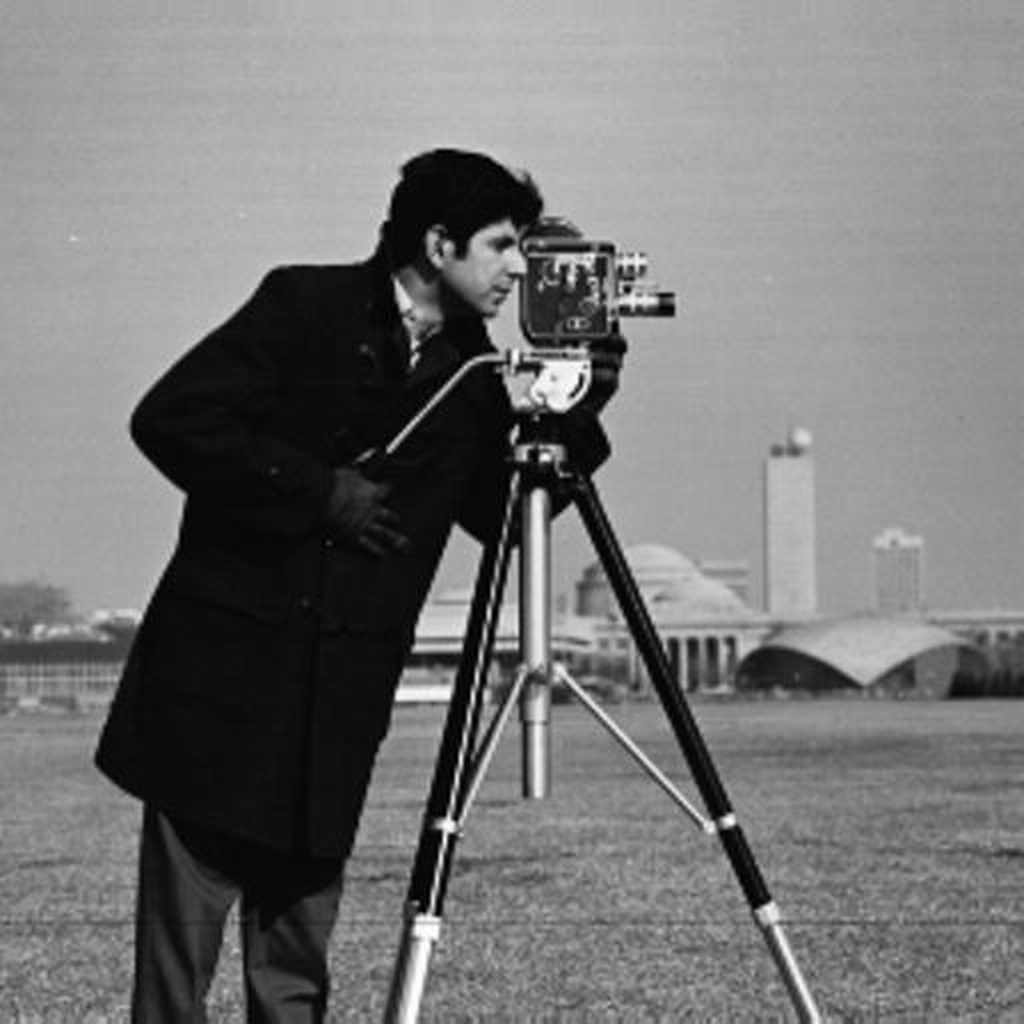

In [50]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method


scaled_image = original_image.resize(
    (width * cx, height * cy),
    Image.Resampling.LANCZOS
)

display(scaled_image)


In [51]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")

# Save the scaled image
scaled_image.save("images/task1_1_scaled.jpg")

# Print the sizes
print("Original size:", original_image.size)
print("Scaled size:", scaled_image.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [52]:
# Non-uniform scaling factors
cx = 2
cy = 1

new_width = int(width * cx)
new_height = int(height * cy)

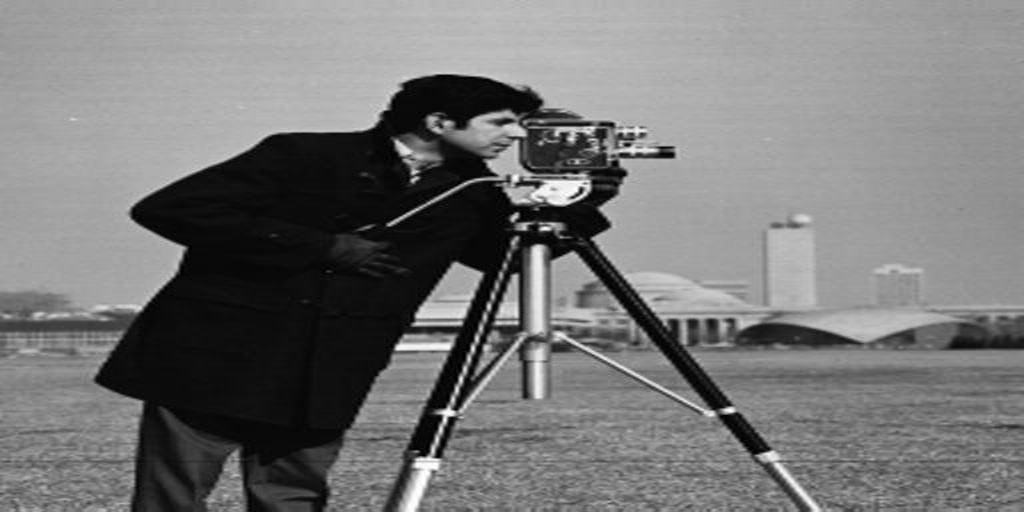

In [53]:
nonuniform_scaled_image = original_image.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

display(nonuniform_scaled_image)

In [54]:
# Save the non-uniformly scaled image
nonuniform_scaled_image.save("images/task1_1_nonuniform_scaled.jpg")

print("Original size:", original_image.size)
print("Non-uniform scaled size:", nonuniform_scaled_image.size)

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

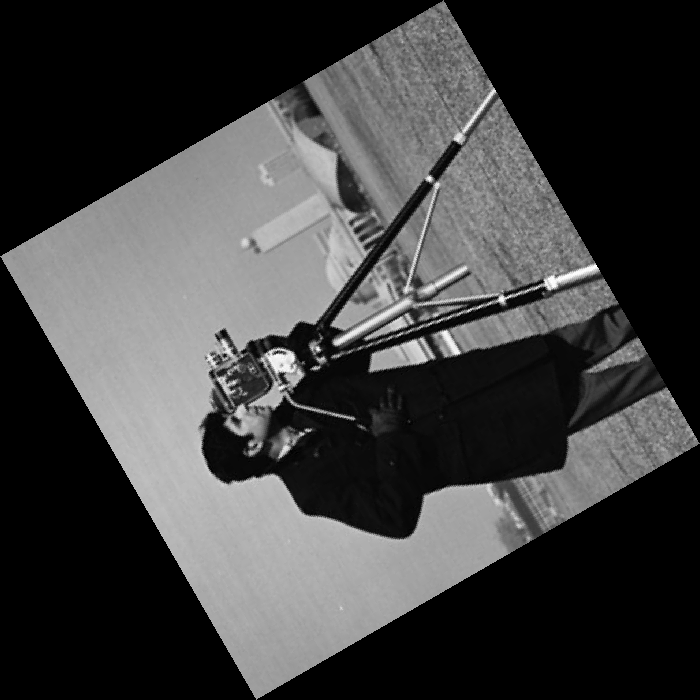

In [55]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_image = original_image.rotate(
    120,
    expand=True
)

display(rotated_image)
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_image.save("images/task1_2_rotated.jpg")

### 3. Shear

In [56]:
# -- c. Get the image dimensions ────────────────────
width, height = original_image.size

print("Width:", width)
print("Height:", height)

Width: 512
Height: 512


In [57]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
# X-axis shear
shx = 0.5
shy = 0.0

# New canvas size
new_width = int(round(width + abs(shx) * height))
new_height = int(round(height + abs(shy) * width))

print("Shear factors:", shx, shy)
print("New canvas size:", new_width, new_height)

Shear factors: 0.5 0.0
New canvas size: 768 512


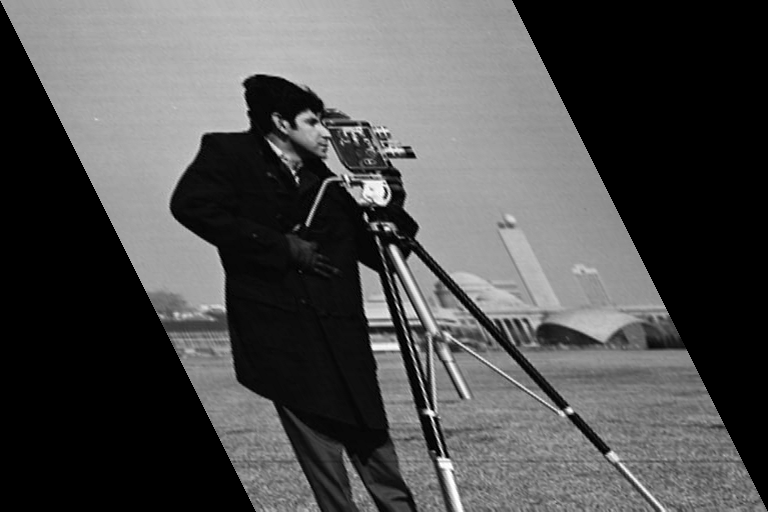

In [58]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared_image = original_image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

display(sheared_image)

In [59]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save("images/task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

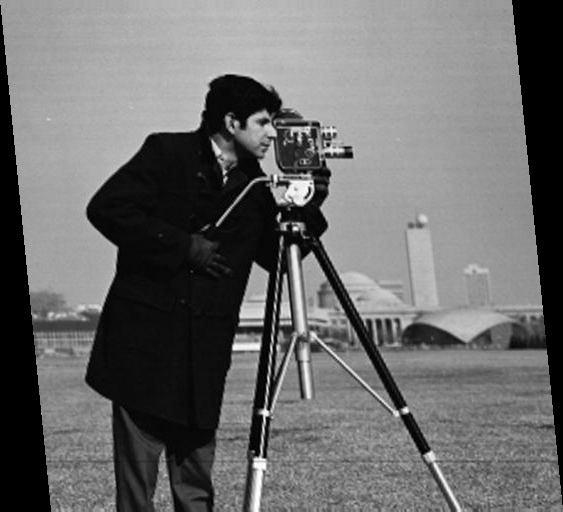

In [60]:
shx = 0.1
shy = 0.0

new_width = int(round(width + abs(shx) * height))
new_height = int(round(height + abs(shy) * width))

shear_01 = original_image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

display(shear_01)
shear_01.save("images/shear_x_0.1.jpg")

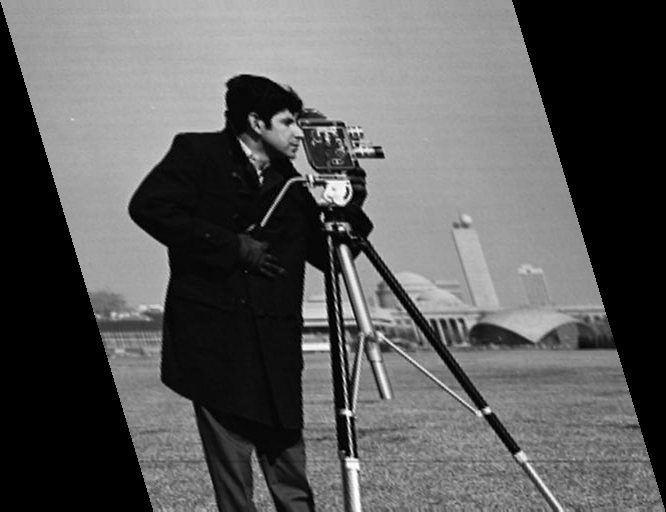

In [61]:
shx = 0.3
shy = 0.0

new_width = int(round(width + abs(shx) * height))
new_height = int(round(height + abs(shy) * width))

shear_03= original_image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

display(shear_03)
shear_03.save("images/shear_x_0.3.jpg")

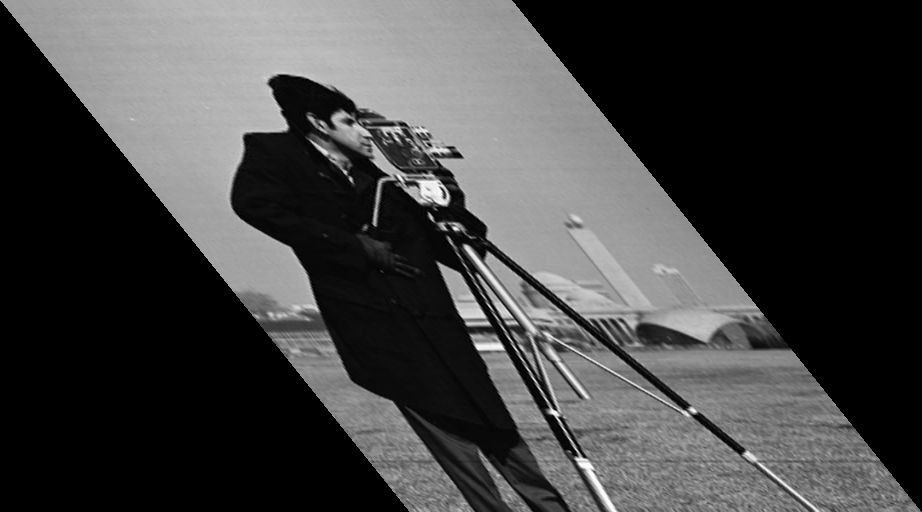

In [62]:
shx = 0.8
shy = 0.0

new_width = int(round(width + abs(shx) * height))
new_height = int(round(height + abs(shy) * width))

shear_08= original_image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

display(shear_08)
shear_08.save("images/shear_x_0.8.jpg")

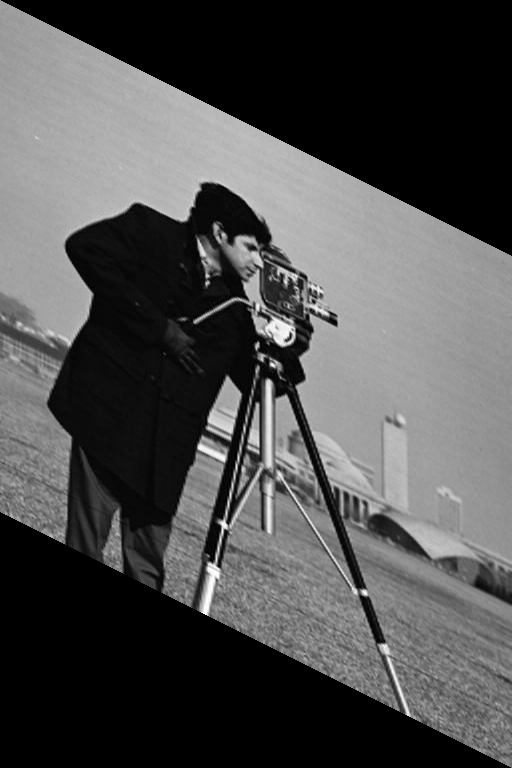

In [63]:
shx = 0.0
shy = 0.5

new_width = int(round(width + abs(shx) * height))
new_height = int(round(height + abs(shy) * width))

shear_y = original_image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

display(shear_y)
shear_y.save("images/shear_y_0.5.jpg")

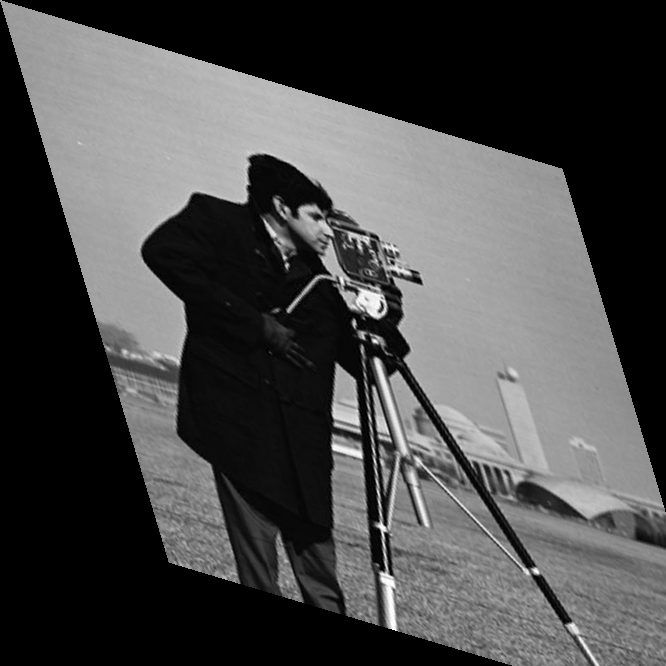

In [64]:
shx = 0.3
shy = 0.3

new_width = int(round(width + abs(shx) * height))
new_height = int(round(height + abs(shy) * width))

shear_xy = original_image.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

display(shear_xy)
shear_xy.save("images/shear_xy.jpg")

# Intensity Transformations
Negative · Log · Power Law (Gamma)

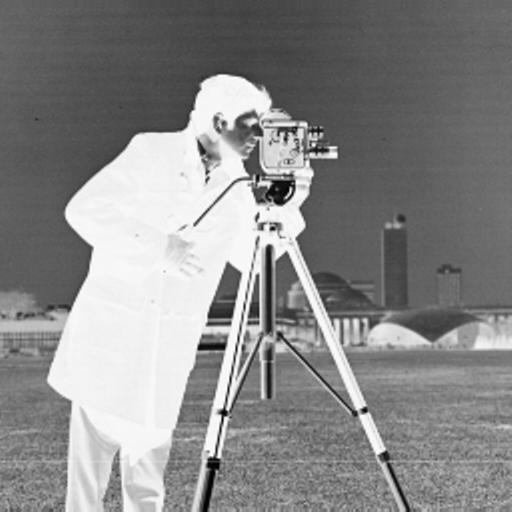

In [65]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

img_array = np.array(original_image)

negative_array = 255 - img_array

negative_image = Image.fromarray(negative_array)

display(negative_image)
negative_image.save("images/task2_1_negative_numpy.jpg")


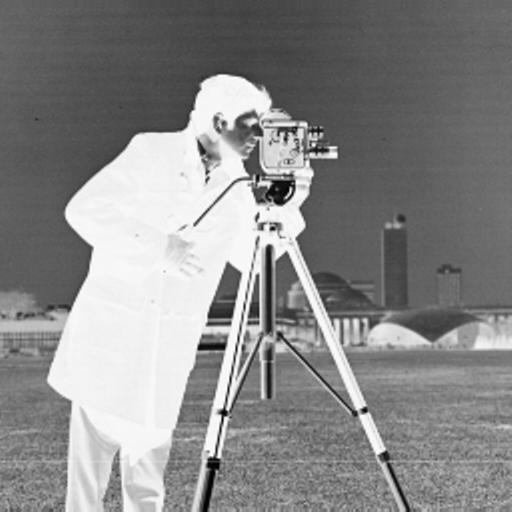

In [66]:
# Method 2: PIL's ImageOps
negative_image_pil = ImageOps.invert(original_image)

display(negative_image_pil)
negative_image_pil.save("images/task2_1_negative_pil.jpg")

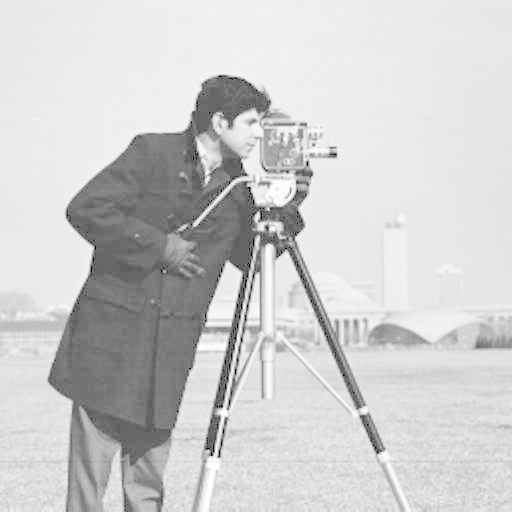

In [67]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel
img_array = np.array(original_image).astype(np.float32)

c = 255 / np.log(1 + 255)

log_array = c * np.log(1 + img_array)

log_image = Image.fromarray(np.uint8(log_array))

display(log_image)
log_image.save("images/task2_2_log.jpg")

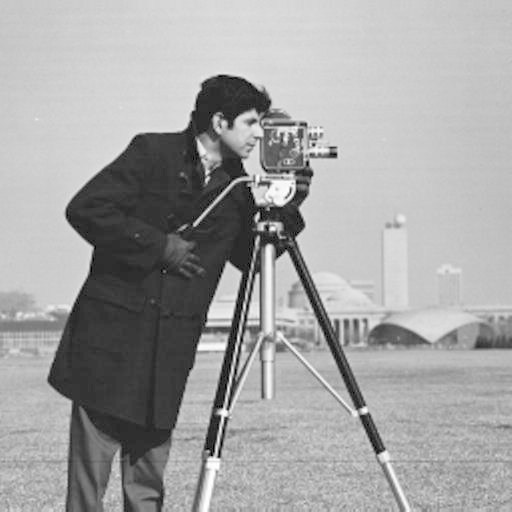

In [68]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

img_array = np.array(original_image).astype(np.float32) / 255.0

gamma_array = 255 * np.power(img_array, gamma)

gamma_image = Image.fromarray(np.uint8(gamma_array))

display(gamma_image)

In [69]:
gamma_image.save("images/task2_3_gamma.jpg")